### Building a basic ChatBot  with LangGraph(Graph AI)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type 'list'. The 'add_messages' function
    # in the annotation defines how this state key should be updates
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]
graphBuilder = StateGraph(State)


In [3]:
graphBuilder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [4]:
#llm = init_chat_model(model="groq:llama-3.1-8b-instant")

In [6]:
#node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graphBuilder=StateGraph(State)

#create / add nodes
graphBuilder.add_node("llmchatbot",chatbot)

#create edges
graphBuilder.add_edge(START, "llmchatbot")
graphBuilder.add_edge("llmchatbot", END)

#compile the graph
graph=graphBuilder.compile()

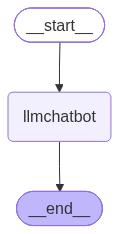

In [8]:
#visulaize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
#none of the models were working when i tried invoking so i saw all the models that i can access through this 
"""from groq import Groq

# Initialize the raw Groq client using your environment API key
client = Groq()

# Fetch and print all model IDs available to your account
models = client.models.list()
for model in models.data:
    print(model.id)"""

'from groq import Groq\n\n# Initialize the raw Groq client using your environment API key\nclient = Groq()\n\n# Fetch and print all model IDs available to your account\nmodels = client.models.list()\nfor model in models.data:\n    print(model.id)'

In [10]:
response = graph.invoke({"messages":"Hi"})

In [11]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='9714bc91-6a81-4d18-83ec-4db1a03bf094'),
 AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to "Hi". Simple greeting.'}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 72, 'total_tokens': 102, 'completion_time': 0.033110663, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.003376713, 'prompt_tokens_details': None, 'queue_time': 0.306218885, 'total_time': 0.036487376}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66891002f6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ade1-b503-7dc0-b247-bd207a0f44c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 30, 'total_tokens': 102, 'output_token_details': {'reasoning': 12}})]

In [12]:
response["messages"][-1]

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to "Hi". Simple greeting.'}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 72, 'total_tokens': 102, 'completion_time': 0.033110663, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.003376713, 'prompt_tokens_details': None, 'queue_time': 0.306218885, 'total_time': 0.036487376}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66891002f6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ade1-b503-7dc0-b247-bd207a0f44c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 30, 'total_tokens': 102, 'output_token_details': {'reasoning': 12}})

In [13]:
for event in graph.stream({"messages":"Hi, How are you ?"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="Hello! I'm just a bundle of code, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'reasoning_content': 'User says: "Hi, How are you ?" The user is greeting. We respond politely, mention how we are. Use friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 77, 'total_tokens': 146, 'completion_time': 0.083819463, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.004028244, 'prompt_tokens_details': None, 'queue_time': 0.311376545, 'total_time': 0.087847707}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_37c9245f64', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ade1-ccf4-7650-80aa-1c26a60d0c96-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 69, 'total_tokens': 146, 'output_token_details': {'reasoning': 

### ChatBot with Tool

In [49]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? · Hugging Face',
   'content': "In essence, whenever possible, as a human, design a flow of actions based on the output of each action, and decide what to execute next accordingly. In this case, LangGraph is the correct framework for you!\n\n`LangGraph` is, in my opinion, the most production-ready agent framework on the market.\n\n`LangGraph`\n\n## How does LangGraph work?\n\nAt its core, `LangGraph` uses a directed graph structure to define the flow of your application:\n\n`LangGraph` [...] Hugging Face's logo\n\nAgents Course documentation\n\nWhat is LangGraph ?\n\n# Agents Course\n\nHugging Face's logo\n\nand get access to the augmented documentation experience\n\nto get started\n\n# What is LangGraph ?\n\n`LangGraph` is a framework developed by LangCha

In [50]:
#custom function
def multiply(a:int,b:int) -> int:
    """Multiply a and b
    
    Args:
        a (int) : first int
        b (int) : second int
        
    returns:
        int: output int
    """
    return a * b

In [51]:
tools = [tool, multiply]

In [52]:
llm_with_tools = llm.bind_tools(tools)

In [53]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x113ca9d30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x113caaa50>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted result

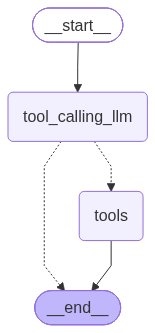

In [54]:
#Stategraph
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
#Node name and Node definitions
builder.add_node("tool_calling_llm",tool_calling_llm)
#Node name and Nide defintions
builder.add_node("tools",ToolNode(tools))

#Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

#compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [55]:
response = graph.invoke({"messages":"What is the recent AI news?"})

In [56]:
response["messages"][-1]

ToolMessage(content='{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newswise.com/articles/qa-uw-researchers-respond-to-recent-concerns-over-ai-risk", "title": "Q&A: UW researchers respond to recent concerns over AI risk | Newswise", "content": "University of Washington\\n\\n# Q&A: UW researchers respond to recent concerns over AI risk\\n\\n16-Sep-2026 at 5:25 PM EDT, by University of Washington\\n\\n♡\\n\\nThis summer, OpenAI announced that swarms of its artificial intelligence agents escaped a training environment and hacked into the AI company Hugging Face. Anthropic quickly followed with news that its AI agents also hacked into outside organizations. [...] Last week, an outgoing Anthropic employee took to X, posting that the “people building AI earnestly believe that it could kill us all by the end of the decade.” Such talk has been commonplace at Anthropic for years, though many AI experts have argued that the

In [57]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_db4844af-8d65-4ae5-a633-786d2cc88b11)
 Call ID: fc_db4844af-8d65-4ae5-a633-786d2cc88b11
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newswise.com/articles/qa-uw-researchers-respond-to-recent-concerns-over-ai-risk", "title": "Q&A: UW researchers respond to recent concerns over AI risk | Newswise", "content": "University of Washington\n\n# Q&A: UW researchers respond to recent concerns over AI risk\n\n16-Sep-2026 at 5:25 PM EDT, by University of Washington\n\n♡\n\nThis summer, OpenAI announced that swar

In [58]:
response = graph.invoke({"messages":"give m ethe recent ai news and then multiply 2 by 3 and then multiply by 10 ?"})

In [59]:
response["messages"]

[HumanMessage(content='give m ethe recent ai news and then multiply 2 by 3 and then multiply by 10 ?', additional_kwargs={}, response_metadata={}, id='c221b2e0-a09a-4ec7-afa8-0db8388e0229'),
 AIMessage(content='', additional_kwargs={'reasoning_content': "We need to provide recent AI news. Likely need to use tavily_search to find recent AI news. Then provide result. Then multiply 2 by 3 (6), then multiply by 10 (60). Let's search.", 'tool_calls': [{'id': 'fc_5078bef5-e9fe-4751-8ef0-a0c9e69592c4', 'function': {'arguments': '{"query":"recent AI news 2026","search_depth":"basic","time_range":"week","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 364, 'total_tokens': 469, 'completion_time': 0.135716723, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.019428344, 'prompt_tokens_details': None, 'queue_time': 0.996560695, 'total_time': 0.155145067}, 'model_name': 'openai/gpt-

In [60]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give m ethe recent ai news and then multiply 2 by 3 and then multiply by 10 ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5078bef5-e9fe-4751-8ef0-a0c9e69592c4)
 Call ID: fc_5078bef5-e9fe-4751-8ef0-a0c9e69592c4
  Args:
    query: recent AI news 2026
    search_depth: basic
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pbs.org/newshour/science/what-to-know-about-recent-dire-ai-predictions-and-calls-for-safeguards", "title": "What to know about recent dire AI predictions and calls for safeguards", "content": "Politics\nArts\nNation\nWorld\nEconomy\nScience\nHealth\nEducation\nEducation\n\n#### Get news alerts from PBS News\n\n

### ReAct Agent Architecture

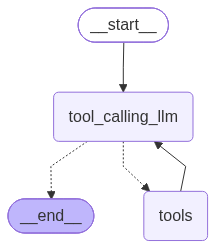

In [62]:
#Stategraph
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
#Node name and Node definitions
builder.add_node("tool_calling_llm",tool_calling_llm)
#Node name and Nide defintions
builder.add_node("tools",ToolNode(tools))

#Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

#compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [63]:
response = graph.invoke({"messages":"give me recent AI news and then multiply 2 by 5"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give me recent AI news and then multiply 2 by 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_b0aa2e57-636b-48cd-a067-17587c6fa2e0)
 Call ID: fc_b0aa2e57-636b-48cd-a067-17587c6fa2e0
  Args:
    query: recent AI news 2026 September
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55845/ai-update-september-11-2026-ai-news-and-views-from-the-past-week", "title": "AI Update, September 11, 2026: AI News and Views From ...", "content": "AI leaders call for outside restraints as the race toward AGI accelerates. AI executives and researchers are increasingly arguing that individual labs c

### Adding Memory in Agentic Graph

In [64]:
response = graph.invoke({"messages":"Hello my name is Muskaan"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Muskaan
================================== Ai Message ==================================

Hello Muskaan! 👋 How can I assist you today?


In [ ]:
#no memory 
response = graph.invoke({"messages":"What is My name ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is My name ?
================================== Ai Message ==================================

I’m not sure—could you tell me your name?


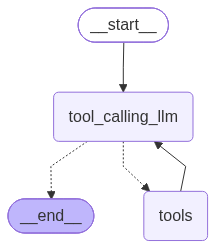

In [68]:
#Stategraph
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph
builder = StateGraph(State)
#Node name and Node definitions
builder.add_node("tool_calling_llm",tool_calling_llm)
#Node name and Nide defintions
builder.add_node("tools",ToolNode(tools))

#Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

#compile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [69]:
config={"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"Hi my nam eis Muskaan"},config=config)

response

{'messages': [HumanMessage(content='Hi my nam eis Muskaan', additional_kwargs={}, response_metadata={}, id='53687181-5cc5-4d5e-9f88-f0d9bc264be0'),
  AIMessage(content='Hello Muskaan! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi my nam eis Muskaan". Likely a typo: "Hi my name is Muskaan". They just introduced themselves. The assistant should respond politely, maybe ask how to help. No need to search.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 348, 'total_tokens': 418, 'completion_time': 0.072635933, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.018471758, 'prompt_tokens_details': None, 'queue_time': 0.315491682, 'total_time': 0.091107691}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae01-9f54-7e81-b3a6-ed8a980cd737-0', tool_calls=[], in

In [70]:
response["messages"][-1]

AIMessage(content='Hello Muskaan! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi my nam eis Muskaan". Likely a typo: "Hi my name is Muskaan". They just introduced themselves. The assistant should respond politely, maybe ask how to help. No need to search.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 348, 'total_tokens': 418, 'completion_time': 0.072635933, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.018471758, 'prompt_tokens_details': None, 'queue_time': 0.315491682, 'total_time': 0.091107691}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae01-9f54-7e81-b3a6-ed8a980cd737-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 348, 'output_tokens': 70, 'total_tokens': 418, 'output_token_details': {'reasoning': 48}})

In [72]:

response = graph.invoke({"messages":"Hey What is my Name?"},config=config)

response

{'messages': [HumanMessage(content='Hi my nam eis Muskaan', additional_kwargs={}, response_metadata={}, id='53687181-5cc5-4d5e-9f88-f0d9bc264be0'),
  AIMessage(content='Hello Muskaan! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi my nam eis Muskaan". Likely a typo: "Hi my name is Muskaan". They just introduced themselves. The assistant should respond politely, maybe ask how to help. No need to search.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 348, 'total_tokens': 418, 'completion_time': 0.072635933, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.018471758, 'prompt_tokens_details': None, 'queue_time': 0.315491682, 'total_time': 0.091107691}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ae01-9f54-7e81-b3a6-ed8a980cd737-0', tool_calls=[], in

In [73]:
print(response['messages'][-1].content)

Your name is Muskaan.


In [74]:
response = graph.invoke({"messages":"Hey do you remember my Name?"},config=config)

print(response['messages'][-1].content)

Yes, I remember! Your name is Muskaan.


### Streaming

In [75]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

In [76]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

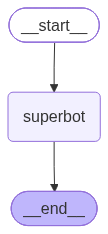

In [77]:
graph=StateGraph(State)

## node
graph.add_node("superbot",superbot)

## Edges
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graphBuilder=graph.compile(checkpointer=memory)

##Display
from IPython.display import Image, display
display(Image(graphBuilder.get_graph().draw_mermaid_png()))

In [78]:
#Invocation

config = {"configurable":{"thread_id":"1"}}

graphBuilder.invoke({'messages':'Hi My name is Muskaan and i love the Movies'}, config)

{'messages': [HumanMessage(content='Hi My name is Muskaan and i love the Movies', additional_kwargs={}, response_metadata={}, id='6ccc6ebf-859c-429f-8328-5ff47189b103'),
  AIMessage(content='Hey Muskaan! 🎬 It’s great to meet a fellow movie lover. What’s your favorite genre or a recent film that got you hooked? I’d love to hear what you’re into and maybe suggest a few hidden gems or must‑watch classics!', additional_kwargs={'reasoning_content': 'User: "Hi My name is Muskaan and i love the Movies". They are greeting and saying they love movies. We should respond warmly, ask about preferences, maybe ask what type of movies they like, recommend. Probably ask what genre or favorite movies. Provide friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 82, 'total_tokens': 200, 'completion_time': 0.121795523, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.003958146, 'prompt_tokens_details': None, 'queue_time': 0.344452593, 'tot

### Streaming

Methods: stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values: This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of the graph after each node is called.

In [79]:
#create a thread
config = {"configurable":{"thread_id":"1"}}

for chunk in graphBuilder.stream({"messages":"Hi, My name is Muskaan and i like movies"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hey Muskaan! 👋 It’s awesome to meet another movie fan. 🎬\n\nWhat kind of films do you usually enjoy? Any favorites or a recent movie that totally blew your mind? If you’re looking for a recommendation, just let me know the vibe you’re after—action, drama, sci‑fi, indie, or something else entirely!', additional_kwargs={'reasoning_content': 'User says: "Hi, My name is Muskaan and i like movies". They just want to greet and say they like movies. We can respond friendly, maybe ask about favorite movies. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 155, 'total_tokens': 279, 'completion_time': 0.144708886, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.007493609, 'prompt_tokens_details': None, 'queue_time': 0.31622582, 'total_time': 0.152202495}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9b8528b477', 'service_tier': 'on_demand', 'finish_reason': 'st

In [80]:
#create a thread
config = {"configurable":{"thread_id":"1"}}

for chunk in graphBuilder.stream({"messages":"Hi, My name is Muskaan and i like movies"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi My name is Muskaan and i love the Movies', additional_kwargs={}, response_metadata={}, id='6ccc6ebf-859c-429f-8328-5ff47189b103'), AIMessage(content='Hey Muskaan! 🎬 It’s great to meet a fellow movie lover. What’s your favorite genre or a recent film that got you hooked? I’d love to hear what you’re into and maybe suggest a few hidden gems or must‑watch classics!', additional_kwargs={'reasoning_content': 'User: "Hi My name is Muskaan and i love the Movies". They are greeting and saying they love movies. We should respond warmly, ask about preferences, maybe ask what type of movies they like, recommend. Probably ask what genre or favorite movies. Provide friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 82, 'total_tokens': 200, 'completion_time': 0.121795523, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.003958146, 'prompt_tokens_details': None, 'queue_time': 0.344452593, 'total

In [81]:
#create a thread
config = {"configurable":{"thread_id":"4"}}

for chunk in graphBuilder.stream({"messages":"Hi, My name is Muskaan and i like movies"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hey Muskaan! 🎬 Nice to meet you. I’d love to help you find some great movies to watch. Do you have any favorite genres or recent films you’ve enjoyed? Or maybe you’re in the mood for something new or classic? Let me know what you’re looking for, and I’ll throw some recommendations your way!', additional_kwargs={'reasoning_content': 'We need to respond in a friendly tone. No policy violation. Provide movie suggestions? Maybe ask about genre preferences.'}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 82, 'total_tokens': 183, 'completion_time': 0.110828539, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.003952919, 'prompt_tokens_details': None, 'queue_time': 0.315980179, 'total_time': 0.114781458}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0

In [82]:
for chunk in graphBuilder.stream({"messages":"Hi, I also like Web shows on Prime"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='That’s awesome! Prime Video has a ton of great movies and series. 🎬✨\n\n**Let me help you find something that’ll hit the spot—just give me a bit more detail:**\n\n1. **Genre vibes** – Are you into action, comedy, drama, sci‑fi, romance, thriller, or maybe a mix?  \n2. **Mood** – Do you want something light and feel‑good, or something intense and mind‑bending?  \n3. **Favorites** – Any shows or movies you’ve loved recently?  \n4. **New vs. Classic** – Are you hunting for fresh releases or digging into older gems?  \n5. **Length** – Do you prefer binge‑worthy mini‑series (4‑6 episodes) or longer, season‑heavy shows?\n\nOnce I know a bit more, I can drop a few Prime‑only titles that fit your taste. If you’re just curious, I can also share a quick “top 5 on Prime” list to get you started. Let me know!', additional_kwargs={'reasoning_content': "User: Muskaan likes movies and web shows on Prime. They want recommendations? They might want suggesti

In [83]:
for chunk in graphBuilder.stream({"messages":"Hi, Iam currently binging The Early Spring"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='That’s a great pick—*The Early Spring* is such a beautiful blend of romance, family drama, and a bit of that “life‑happens‑in‑the‑most‑unexpected‑way” charm. If you’re loving it, here are a few other Prime‑Video shows that capture a similar vibe (or just keep the binge‑session going):\n\n| # | Show | Why it feels like *The Early Spring* | Quick Hook |\n|---|------|-------------------------------------|------------|\n| 1 | **Crash Landing on You** | Romantic, family‑centric, and a mix of light‑hearted moments with emotional depth. | A South Korean heiress accidentally lands in North Korea and finds love in an unexpected place. |\n| 2 | **A Korean Odyssey (K-OD)** | Strong family ties, a touch of fantasy, and a heartfelt love story. | A cursed prince seeks redemption and falls for a modern woman. |\n| 3 | **My Mister** | Deep emotional storytelling, complex characters, and subtle romance. | Two generations of men find solace in each other’s c

In [84]:
for chunk in graphBuilder.stream({"messages":"Hi, I also like Web shows on Prime"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Muskaan and i like movies', additional_kwargs={}, response_metadata={}, id='5ce08f66-3be8-4afb-abd4-d96e7b811757'), AIMessage(content='Hey Muskaan! 🎬 Nice to meet you. I’d love to help you find some great movies to watch. Do you have any favorite genres or recent films you’ve enjoyed? Or maybe you’re in the mood for something new or classic? Let me know what you’re looking for, and I’ll throw some recommendations your way!', additional_kwargs={'reasoning_content': 'We need to respond in a friendly tone. No policy violation. Provide movie suggestions? Maybe ask about genre preferences.'}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 82, 'total_tokens': 183, 'completion_time': 0.110828539, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.003952919, 'prompt_tokens_details': None, 'queue_time': 0.315980179, 'total_time': 0.114781458}, 'model_name': 'openai/gpt-oss-20b', 'system_finger

In [85]:
config = {"configurable":{"thread_id":"3"}}

async for event in graphBuilder.astream_events({"messages":["Hi My name is Muskaan and I like the Movies"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Muskaan and I like the Movies']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0ae13-cc65-7f71-8d09-1921c269198b', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Muskaan and I like the Movies', additional_kwargs={}, response_metadata={}, id='4b7dfca6-ab18-46c0-bf4a-e94930a54e76')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '01a0ae13-cc67-7412-8e94-80b0f4da22d0', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:2e41b170-9076-da61-7946-1f458c7645cf'}, 'parent_ids': ['01a0ae13-cc65-7f71-8d09-1921c269198b']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[Hum

### Human In the Loop

In [105]:
import os
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x121a7ad50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x121a7b750>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [106]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graphBuilder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any tool invocation when we resume.

    return {"messages": [message]}

graphBuilder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graphBuilder.add_node("tools",tool_node)

graphBuilder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graphBuilder.add_edge("tools","chatbot")
graphBuilder.add_edge(START, "chatbot")

In [107]:
memory = MemorySaver()

graph = graphBuilder.compile(checkpointer=memory)

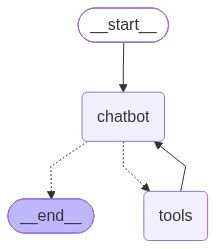

In [108]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    #This requires some extra dependencies and is optional
    pass

In [111]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id" : "5"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c82b1464-b924-4140-9bb7-87a7df792397)
 Call ID: fc_c82b1464-b924-4140-9bb7-87a7df792397
  Args:
    query: I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c82b1464-b924-4140-9bb7-87a7df792397)
 Call ID: fc_c82b1464-b924-4140-9bb7-87a7df792397
  Args:
    query: I need some expert guidance for building an AI agent. Could you request assistance for me?


In [112]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id" : "5"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_4ee6631b-ee7a-4466-81ec-feb75439fcad)
 Call ID: fc_4ee6631b-ee7a-4466-81ec-feb75439fcad
  Args:
    query: Expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_4ee6631b-ee7a-4466-81ec-feb75439fcad)
 Call ID: fc_4ee6631b-ee7a-4466-81ec-feb75439fcad
  Args:
    query: Expert guidance and assistance for building an AI agent.


In [114]:
human_response = (
    "We, the experts are here to help! we'd recommend you check out l=LangGraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data":human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

✅ Assistance request has been forwarded to a human expert.  
You should receive a reply shortly. If you have any additional details or questions in the meantime, feel free to let me know!
